In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import requests
from io import StringIO
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from scipy.stats import norm
from scipy.stats import t
# dependency on pyarrow -> include in toml

1. Universe Selection
2. Factor Exploration
3. Factor Model Decomposition
4. Portfolio Risk Decomposition
5. VaR Analysis

# Universe Selection
Selecting the most liquid stocks

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()

sp500 = pd.read_html(StringIO(response.text))[0]
sp500tickers = sp500['Symbol'].tolist()
sp500tickers = [t.replace('.', '-') for t in sp500tickers] # Cleaning tickers, some of them have dots instead of dashes

In [3]:
def get_prices(tickers, start, end, path):
    folder = os.path.dirname(path)
    
    if folder:
        os.makedirs(folder, exist_ok= True)
        
    if os.path.exists(path):
        return pd.read_parquet(path)
    
    data = yf.download(tickers, start = start, end = end)
    data.to_parquet(path)
    return data

In [4]:
start = "2015-01-01"
end = "2025-01-01"
liquidity_check = get_prices(sp500tickers, start, end, path = "SP500.parquet")

[**********************52%                       ]  262 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[**********************94%********************   ]  474 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")


In [5]:
close = liquidity_check["Close"]
volume = liquidity_check["Volume"]

full_history = close.dropna(axis=1, how="any").columns
volume_clean = volume[full_history]

avg_volume = volume_clean.mean(axis=0).sort_values(ascending=False)
top30_tickers = avg_volume.head(30).index.tolist()

# Factor Exploration

In [6]:
# Fama French 3 Factors Daily
path = "F-F_Research_Data_Factors_daily.csv"
factors = pd.read_csv(path)
factors["Date"] = pd.to_datetime(factors["Date"], format="%Y%m%d")
factors.set_index("Date", inplace=True)
cols = ["Mkt-RF", "SMB", "HML","RF"]
factors[cols] /= 100 # Rescaling factors

# Factor Model Estimation

In [7]:
financials = liquidity_check.loc[:, (slice(None), top30_tickers)]
returns = financials["Close"].pct_change().dropna()
df = factors.join(returns, how = "inner")

In [8]:
# Add a OLS assumption checker -> graphs & assumptions

In [9]:
X = df[["Mkt-RF", "SMB", "HML"]]
X = sm.add_constant(X)

stock_cols = returns.columns

results = []

for stock in stock_cols:
    y = df[stock] - df["RF"]

    model = sm.OLS(y, X).fit(cov_type = 'HAC', cov_kwds = {'maxlags':5})


    results.append({
        "Ticker": stock,
        "Alpha": model.params["const"],
        "Beta_Mkt": model.params["Mkt-RF"],
        "Beta_SMB": model.params["SMB"],
        "Beta_HML": model.params["HML"],
        "Residual_Var": model.resid.var(),
        "R2": model.rsquared,
        "Alpha_pval": model.pvalues["const"],
        "Mkt_pval": model.pvalues["Mkt-RF"],
        "SMB_pval": model.pvalues["SMB"],
        "HML_pval": model.pvalues["HML"],
    })

results_df = pd.DataFrame(results)
print(results_df)

   Ticker     Alpha  Beta_Mkt  Beta_SMB  Beta_HML  Residual_Var        R2  \
0    NVDA  0.001739  1.673009  0.019323 -0.939061      0.000474  0.494571   
1    AAPL  0.000399  1.171408 -0.300807 -0.399692      0.000128  0.601484   
2    TSLA  0.001174  1.424337  0.578027 -0.732626      0.000930  0.282437   
3    NFLX  0.000832  1.132172 -0.053181 -0.835136      0.000518  0.313682   
4    AMZN  0.000575  1.124306 -0.203254 -0.741936      0.000209  0.510059   
5     BAC  0.000061  1.259353  0.009116  1.074105      0.000098  0.746000   
6     AMD  0.001298  1.574804  0.274322 -0.771845      0.000956  0.299967   
7       F -0.000241  1.138814  0.443436  0.668333      0.000288  0.436505   
8       T  0.000005  0.638895 -0.236424  0.448555      0.000140  0.313816   
9   GOOGL  0.000279  1.124995 -0.258087 -0.414430      0.000140  0.563211   
10   INTC -0.000554  1.234750 -0.087454 -0.105314      0.000303  0.398729   
11   GOOG  0.000287  1.124135 -0.259460 -0.404760      0.000142  0.558670   

### Rolling Beta Analysis

In [10]:
rolling_results = []

window = max(126, len(df) // 3) #min window size, split into 3

for stock in returns.columns:
    
    for i in range(window, len(df)):
        df_window = df.iloc[i-window:i]
        
        y = df_window[stock] - df_window["RF"]
        X = df_window[["Mkt-RF", "SMB", "HML"]]
        X = sm.add_constant(X)
        
        model = sm.OLS(y, X).fit()
        
        rolling_results.append({
            "Date": df.index[i],
            "Ticker": stock,
            "Beta_Mkt": model.params["Mkt-RF"],
            "Beta_SMB": model.params["SMB"],
            "Beta_HML": model.params["HML"],
        })

rolling_df = pd.DataFrame(rolling_results)

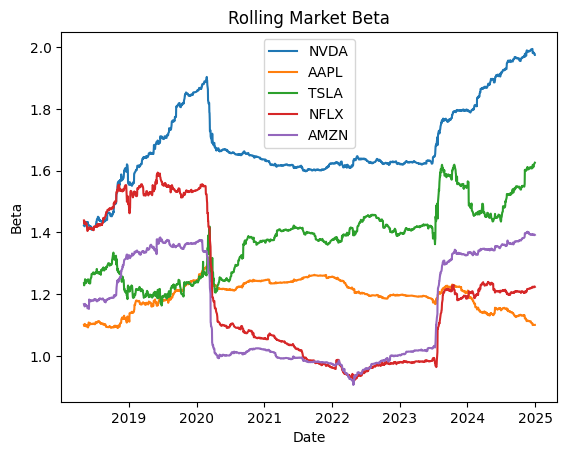

ps. window size is 838 days


In [11]:
# stock = stock_cols[0]  # arbitrary example, possible to change it to a different one
# data = rolling_df[rolling_df["Ticker"] == stock]
# plt.plot(data["Date"], data["Beta_Mkt"])

for stock in stock_cols[:5]: # top 5 most liquid stocks only
    data = rolling_df[rolling_df["Ticker"] == stock]
    plt.plot(data["Date"], data["Beta_Mkt"], label=stock)

plt.title(f"Rolling Market Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.show()
print(f"ps. window size is {window} days")

# Portfolio Risk Decomposition

### Systematic vs Idiosyncratic Risk

In [12]:
equal_weights = np.ones(len(top30_tickers)) / len(top30_tickers)
cov_matrix = returns.cov() * 252
# sns.heatmap(returns.corr(), center=0, cmap="coolwarm");
equal_weights.T @ cov_matrix @ equal_weights

np.float64(0.047380016609897206)

In [13]:
res = results_df.set_index("Ticker").loc[stock_cols]

B = res[["Beta_Mkt", "Beta_SMB", "Beta_HML"]].values
D = np.diag(res["Residual_Var"].values * 252)
Sigma_f = df[["Mkt-RF", "SMB", "HML"]].cov().values * 252 # Calculating on "df", not "factors" -> to have the same time frame
w = equal_weights


var_systematic = w @ B @ Sigma_f @ B.T @ w
var_idiosyncratic = w @ D @ w

var_total = var_systematic + var_idiosyncratic

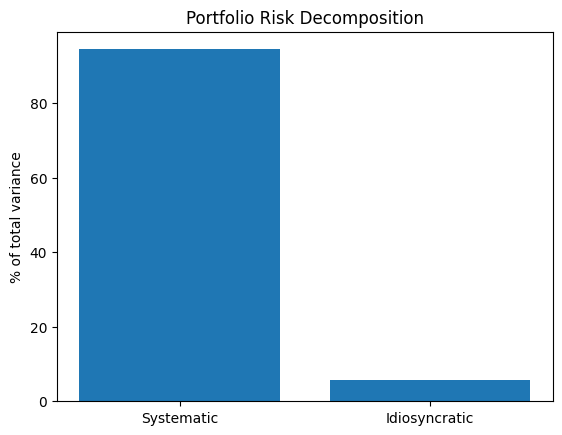

In [14]:
pct_systematic = var_systematic / var_total * 100
pct_idiosyncratic = var_idiosyncratic / var_total * 100

labels = ['Systematic', 'Idiosyncratic']

plt.bar(labels, [pct_systematic,pct_idiosyncratic])
plt.ylabel('% of total variance')
plt.title('Portfolio Risk Decomposition')
plt.show()


### Factor Risk Decomposition

In [15]:
Bw = B.T @ w
factor_contrib = Bw * (Sigma_f @ Bw)
factor_pct = factor_contrib / var_systematic * 100
factor_names = ["Market", "SMB", "HML"]

for f, pct in zip(factor_names, factor_pct):
    print(f"{f}: {pct:.2f}%")

Market: 99.95%
SMB: 0.15%
HML: -0.09%


In [16]:
plot_df = pd.DataFrame({
    "Factor": factor_names,
    "Contribution": factor_pct
})

fig = px.bar(
    plot_df,
    x="Contribution",
    y="Factor",
    orientation="h",
    text="Contribution",
    title="Factor Risk Contribution",
    template="plotly_white"
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
fig.update_layout(title_x=0.5, xaxis_title="% contribution to systematic variance", yaxis_title="")
fig.update_xaxes(ticksuffix = "%")
fig.show()

# Value-at-Risk Analysis

### Historical VaR

In [17]:
port_ret = returns @ w # w defined previously, here it's an equal weighted portfolio

# VaR
q_99 = np.quantile(port_ret, 0.01)
q_95 = np.quantile(port_ret, 0.05)

VaR_99 = -q_99
VaR_95 = -q_95

# CVaR (ES)
CVaR_99 = -port_ret[port_ret <= q_99].mean()
CVaR_95 = -port_ret[port_ret <= q_95].mean()

print(f"Daily VaR 95%: {VaR_95:.2%} | Daily VaR 99%: {VaR_99:.2%}")
print(f"Daily CVaR 95%: {CVaR_95:.2%} | Daily CVaR 99%: {CVaR_99:.2%}")

Daily VaR 95%: 2.10% | Daily VaR 99%: 3.82%
Daily CVaR 95%: 3.29% | Daily CVaR 99%: 5.39%


### Parametric VaR

In [18]:
Sigma_f_daily = df[["Mkt-RF", "SMB", "HML"]].cov().values
D_daily = np.diag(res["Residual_Var"].values)
Sigma_daily = B @ Sigma_f_daily @ B.T + D_daily

mu_p = (returns @ w).mean()
sigma_p = np.sqrt(w.T @ Sigma_daily @ w)

# Using a normal distribution (not printed as it's the nu -> inf case in the summary table)
VaR_99p_n = -(mu_p + norm.ppf(0.01) * sigma_p)
VaR_95p_n = -(mu_p + norm.ppf(0.05) * sigma_p)

# Using a student t distribution
nus = [4, 5, 8, 20]
nu_table = []

for nu in nus:
    scale = np.sqrt((nu - 2) / nu)
    
    VaR_95p_t = -(mu_p + t.ppf(0.05, df=nu) * sigma_p * scale)
    VaR_99p_t = -(mu_p + t.ppf(0.01, df=nu) * sigma_p * scale)
    
    nu_table.append([VaR_95p_t, VaR_99p_t])

nu_table.append([VaR_95p_n, VaR_99p_n])
index = [f"v={nu}" for nu in nus] + ["v -> inf"]

nu_table = pd.DataFrame(
    nu_table,
    index=index,
    columns=["VaR 95%", "VaR 99%"]
)

table = nu_table.map(lambda x: f"{x:.2%}")
table.index.name = "df"
table

,VaR 95%,VaR 99%
df,,
v=4,1.96%,3.51%
v=5,2.03%,3.45%
v=8,2.10%,3.32%
v=20,2.13%,3.17%
v -> inf,2.14%,3.07%


### Stressed VaR

In [25]:
# VaR
q_99_covid = np.quantile(covid_window, 0.01)
q_95_covid = np.quantile(covid_window, 0.05)
VaR_99_covid = -q_99_covid
VaR_95_covid = -q_95_covid

# CVaR (ES)
CVaR_99_covid = -covid_window[covid_window <= q_99_covid].mean()
CVaR_95_covid = -covid_window[covid_window <= q_95_covid].mean()

print(f"Stressed Daily VaR 95%:  {VaR_95_covid:.2%} | Stressed Daily VaR 99%:  {VaR_99_covid:.2%}")
print(f"Stressed Daily CVaR 95%: {CVaR_95_covid:.2%} | Stressed Daily CVaR 99%: {CVaR_99_covid:.2%}")

Stressed Daily VaR 95%:  6.95% | Stressed Daily VaR 99%:  11.83%
Stressed Daily CVaR 95%: 10.04% | Stressed Daily CVaR 99%: 13.17%


In [26]:
var_comparison = pd.DataFrame({
    "Historical (full sample)": [VaR_95, VaR_99],
    "Parametric (normal)":      [VaR_95p_n, VaR_99p_n],
    "Parametric (t, v=5)":      [nu_table.loc["v=5"].values[0], nu_table.loc["v=5"].values[1]],
    "Stressed (COVID)":         [VaR_95_covid, VaR_99_covid],  # add VaR_99_covid too
}, index=["VaR 95%", "VaR 99%"]).map(lambda x: f"{x:.2%}" if isinstance(x, float) else x)

var_comparison

,Historical (full sample),Parametric (normal),"Parametric (t, v=5)",Stressed (COVID)
VaR 95%,2.10%,2.14%,2.03%,6.95%
VaR 99%,3.82%,3.07%,3.45%,11.83%


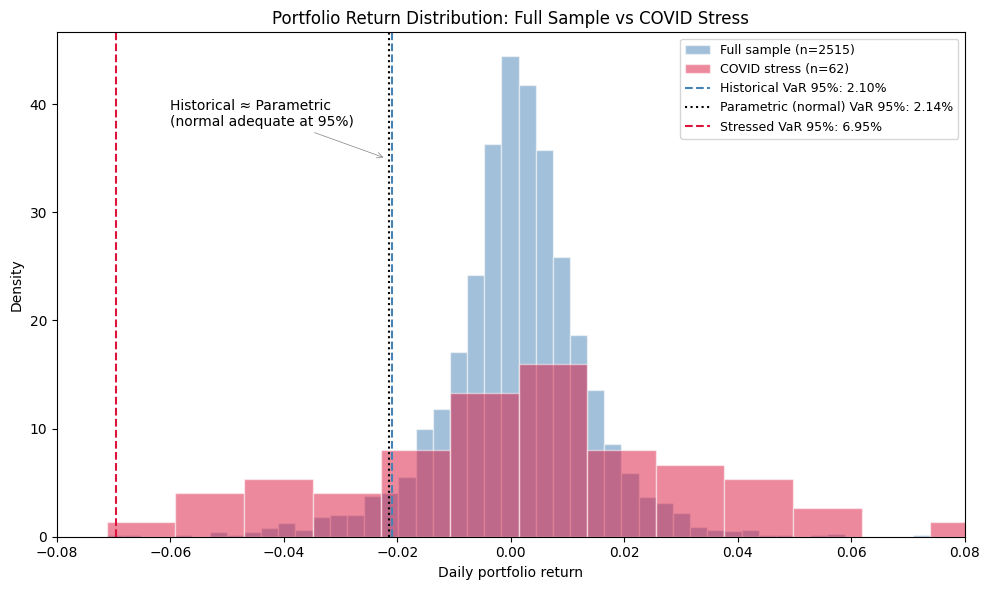

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(port_ret, bins=80, density=True, alpha=0.5, color="steelblue",
        label=f"Full sample (n={len(port_ret)})", edgecolor="white")

ax.hist(covid_window, bins=20, density=True, alpha=0.5, color="crimson",
        label=f"COVID stress (n={len(covid_window)})", edgecolor="white")

ax.axvline(-VaR_95,       color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Historical VaR 95%: {VaR_95:.2%}")
ax.axvline(-VaR_95p_n,    color="black",     linestyle=":",  linewidth=1.5,
           label=f"Parametric (normal) VaR 95%: {VaR_95p_n:.2%}")
ax.axvline(-VaR_95_covid, color="crimson",   linestyle="--", linewidth=1.5,
           label=f"Stressed VaR 95%: {VaR_95_covid:.2%}")

ax.annotate("Historical ≈ Parametric\n(normal adequate at 95%)",
            xy=(-0.022, 35), xytext=(-0.06, 38),
            fontsize=10, ha="left",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))

ax.set_xlim(-0.08, 0.08)
ax.set_xlabel("Daily portfolio return")
ax.set_ylabel("Density")
ax.set_title("Portfolio Return Distribution: Full Sample vs COVID Stress")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()